# Chapter 1: Euclid's Geometry

**Source span.** Printed pages 7-64, PDF pages 19-76, sections 1-5: first look at the *Elements*, ruler-and-compass constructions, Euclid's axiomatic method, the regular pentagon, and newer triangle results.

**Chapter question.** What has to be constructed, assumed, or proved before a familiar Euclidean figure is legitimate?

**Goal.** Recast the opening chapter as inspectable construction data: every figure records its allowed operations, the theorem or assumption that makes the operation legal, and the residual that would expose an incorrect drawing.

This notebook is an original teaching pass. It uses the source only for orientation and terminology; all prose, code, diagrams, certificates, and checks here are newly authored.


## Computational Translation Guide

| Euclid-side idea | Computational representation in this notebook | What the check asks |
| --- | --- | --- |
| Point, straight line, finite segment | coordinate tuples and drawn segments | incidence, collinearity, distance |
| Straightedge step | a line through two already available points | the defining points are distinct |
| Compass step | a circle with constructed center and radius copied from constructed points | radius is positive and intersections exist |
| Construction proof | a certificate table: inputs, primitive operations, created objects, obligations | each claimed equality or incidence has zero residual |
| Common notions and congruence | equality of distances, angles, areas, or rigid-motion invariants | residuals are small, or symbolic identities simplify to zero |
| Hidden assumptions | model predicates such as circle-circle intersection, betweenness, and available rigid motions | a countermodel or numeric residual shows what fails without the assumption |
| Later theorem dependency | directed graph of definitions, assumptions, and propositions | graph is acyclic and every visual theorem has named dependencies |

**Route.** We first certify Euclid I.1 as a construction, then expose the extra existence assumptions behind the picture. We track proof dependencies as a graph, use symbolic checks to explain the pentagon's golden-ratio logic, and close with a lab that tests newer triangle-center results as construction data rather than as memorized facts.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

BOOK_ROOT = Path.cwd().resolve()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Euclid and Beyond book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = "chapter-01"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACTS = ARTIFACT_ROOT / UNIT

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp

from utils.artifacts import assert_artifact, artifact_path, display_artifact, save_json, save_matplotlib
from utils.euclidean import circle_circle_intersections, distance, orientation, polygon_area
from utils.plotting import PALETTE, draw_circle, draw_polygon, draw_segment, label_point, new_figure, set_equal_axes

np.set_printoptions(precision=6, suppress=True)


def book_local(path: Path) -> str:
    return path.resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


## Storyboard And Library Routing

The chapter is planar and proof-heavy, so the main tools are deliberately small:

| Concept | Representation | Library choice | Why |
| --- | --- | --- | --- |
| Ruler/compass constructions | labeled 2D diagrams plus certificate tables | Matplotlib, pandas | precise static drawings and inspectable construction rows |
| Exactness vs paper accuracy | residuals and a rational-plane countermodel | SymPy, NumPy | distinguishes a good drawing from an existence proof |
| Dependencies in Euclid's order | directed proof graph | NetworkX | exposes what a proposition may depend on |
| Pentagon logic | golden-ratio identities and chord checks | SymPy, Matplotlib | exact algebra links the 36-72-72 triangle to equal pentagon sides |
| Newer triangle results | computed centers and nine-point circle | NumPy, Matplotlib | numerical geometry makes collinearity and equal-radius claims testable |

No 3D, mesh, topology, GIS, or computer-vision stack is used because the assigned chapter's objects are straight lines, circles, angles, and theorem dependencies in the plane.


In [2]:
# Shared drawing and checking helpers kept visible in the notebook.
def close_enough(value, tol=1e-10):
    return abs(float(value)) <= tol


def foot_to_line(point, a, b):
    point, a, b = map(lambda p: np.asarray(p, dtype=float), (point, a, b))
    direction = b - a
    t = float(np.dot(point - a, direction) / np.dot(direction, direction))
    return a + t * direction


def circumcenter(a, b, c):
    ax, ay = a
    bx, by = b
    cx, cy = c
    d = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(d) < 1e-12:
        raise ValueError("circumcenter is undefined for collinear points")
    ux = ((ax * ax + ay * ay) * (by - cy) + (bx * bx + by * by) * (cy - ay) + (cx * cx + cy * cy) * (ay - by)) / d
    uy = ((ax * ax + ay * ay) * (cx - bx) + (bx * bx + by * by) * (ax - cx) + (cx * cx + cy * cy) * (bx - ax)) / d
    return np.array([ux, uy], dtype=float)


def draw_extended_line(ax, a, b, **kwargs):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    direction = b - a
    p0 = a - 20 * direction
    p1 = a + 20 * direction
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], **kwargs)


def annotate_equal_marks(ax, pairs, color=PALETTE["gold"]):
    for start, end in pairs:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        mid = (start + end) / 2
        direction = end - start
        normal = np.array([-direction[1], direction[0]])
        normal = normal / np.linalg.norm(normal) * 0.035
        ax.plot([mid[0] - normal[0], mid[0] + normal[0]], [mid[1] - normal[1], mid[1] + normal[1]], color=color, lw=1.5)


## 1. Euclid I.1 As A Construction Certificate

The equilateral triangle is the smallest useful test of Euclid's constructive style. The picture is not the proof. The proof is the certificate: two permitted circles must produce an intersection, and the resulting point must have equal distances from the two endpoints of the original segment.

Inspect the two circles first. The upper and lower intersections are both legal geometric outcomes; choosing one is a harmless orientation choice, but assuming that the intersections exist is not harmless.


In [3]:
A = np.array([0.0, 0.0])
B = np.array([1.0, 0.0])
intersections = [np.array(p) for p in circle_circle_intersections(A, distance(A, B), B, distance(A, B))]
C = max(intersections, key=lambda p: p[1])
D = min(intersections, key=lambda p: p[1])

fig, ax = new_figure(7.2, 5.2)
draw_circle(ax, A, 1.0, label="circle center A, radius AB", color=PALETTE["green"], linestyle="--")
draw_circle(ax, B, 1.0, label="circle center B, radius BA", color=PALETTE["purple"], linestyle="--")
draw_segment(ax, A, B, label="given AB", color=PALETTE["ink"], linewidth=2.4)
draw_segment(ax, A, C, color=PALETTE["blue"], linewidth=2.4)
draw_segment(ax, B, C, color=PALETTE["blue"], linewidth=2.4)
draw_segment(ax, A, D, color=PALETTE["gray"], linewidth=1.2, linestyle=":")
draw_segment(ax, B, D, color=PALETTE["gray"], linewidth=1.2, linestyle=":")
for point, name, offset in [(A, "A", (-0.08, -0.08)), (B, "B", (0.04, -0.08)), (C, "C", (0.03, 0.05)), (D, "D", (0.03, -0.12))]:
    label_point(ax, point, name, offset=offset)
ax.text(0.5, 1.08, "certificate chooses the upper intersection", ha="center", color=PALETTE["blue"], fontsize=10)
ax.text(0.5, -1.14, "the second intersection is another valid orientation", ha="center", color=PALETTE["gray"], fontsize=9)
ax.set_title("Euclid I.1: two compass moves plus two straightedge moves")
ax.set_xlim(-0.35, 1.35)
ax.set_ylim(-1.25, 1.25)
set_equal_axes(ax, margin=0.05)
equilateral_path = save_matplotlib(fig, UNIT, "figures", "equilateral-construction-certificate.png", root=ARTIFACT_ROOT)
plt.close(fig)

eq_residuals = {
    "intersection_count": len(intersections),
    "AB_minus_AC": distance(A, B) - distance(A, C),
    "AB_minus_BC": distance(A, B) - distance(B, C),
    "orientation_ABC": orientation(A, B, C),
}

x = sp.Rational(1, 2)
y = sp.sqrt(3) / 2
symbolic_equilateral = {
    "AC_squared_minus_AB_squared": str(sp.simplify(x**2 + y**2 - 1)),
    "BC_squared_minus_AB_squared": str(sp.simplify((x - 1)**2 + y**2 - 1)),
    "height_is_rational": bool(y.is_rational),
}

equilateral_checks = {"numeric": eq_residuals, "symbolic": symbolic_equilateral}
equilateral_check_path = save_json(equilateral_checks, UNIT, "checks", "equilateral-certificate.json", root=ARTIFACT_ROOT)

certificate_rows = [
    {"certificate": "equilateral_on_AB", "step": 1, "operation": "circle(center=A, radius=AB)", "created": "circle_A", "depends_on": "given segment AB; compass postulate", "obligation": "AB is a positive radius"},
    {"certificate": "equilateral_on_AB", "step": 2, "operation": "circle(center=B, radius=BA)", "created": "circle_B and intersections C,D", "depends_on": "given segment AB; compass postulate; circle intersection assumption", "obligation": "two circles meet"},
    {"certificate": "equilateral_on_AB", "step": 3, "operation": "line(A,C)", "created": "segment AC", "depends_on": "straightedge postulate", "obligation": "A and C are distinct"},
    {"certificate": "equilateral_on_AB", "step": 4, "operation": "line(B,C)", "created": "segment BC", "depends_on": "straightedge postulate", "obligation": "B and C are distinct; AC=AB=BC"},
]

pd.DataFrame(certificate_rows)


,certificate,step,operation,created,depends_on,obligation
0,equilateral_on_AB,1,"circle(center=A, radius=AB)",circle_A,given segment AB; compass postulate,AB is a positive radius
1,equilateral_on_AB,2,"circle(center=B, radius=BA)","circle_B and intersections C,D",given segment AB; compass postulate; circle in...,two circles meet
2,equilateral_on_AB,3,"line(A,C)",segment AC,straightedge postulate,A and C are distinct
3,equilateral_on_AB,4,"line(B,C)",segment BC,straightedge postulate,B and C are distinct; AC=AB=BC


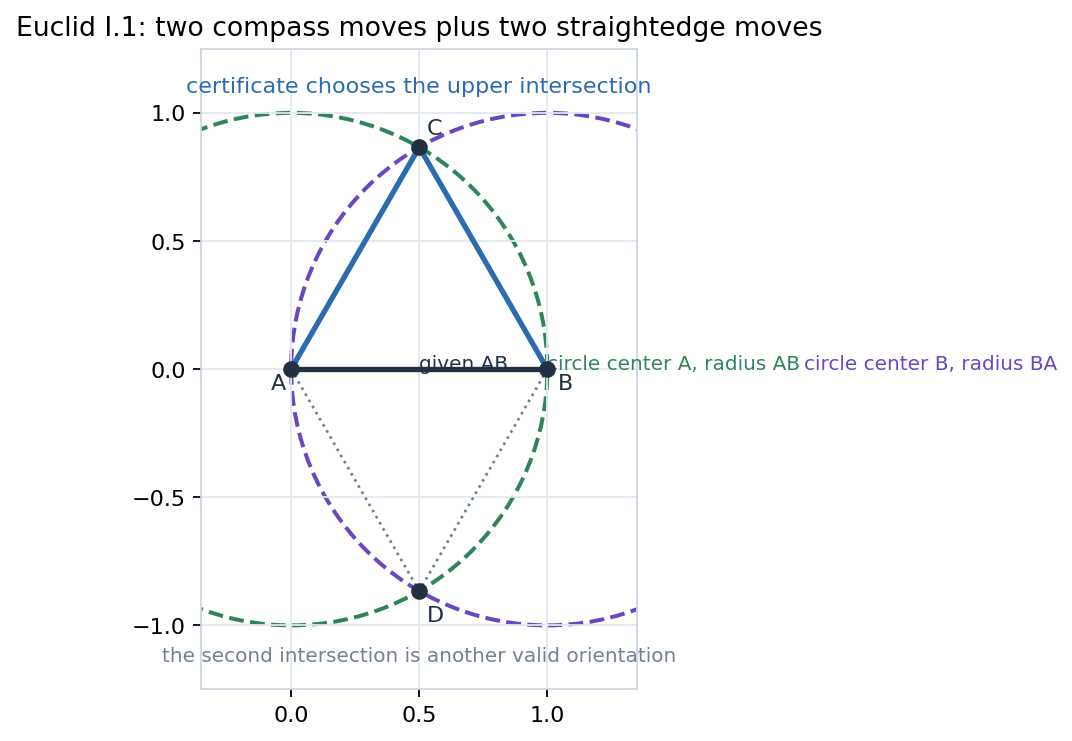

{
  "numeric": {
    "intersection_count": 2,
    "AB_minus_AC": 1.1102230246251565e-16,
    "AB_minus_BC": 1.1102230246251565e-16,
    "orientation_ABC": 0.8660254037844386
  },
  "symbolic": {
    "AC_squared_minus_AB_squared": "0",
    "BC_squared_minus_AB_squared": "0",
    "height_is_rational": false
  }
}


In [4]:
display_artifact(equilateral_path, width=760)
print(json.dumps(equilateral_checks, indent=2))


## 2. Hidden Existence Assumptions

On paper the two circles visibly cross. As a formal proof, visibility is not enough. The construction needs an existence principle for the intersection point. The rational coordinate plane is a useful stress test: it has many familiar-looking points and lines, but the third vertex of an equilateral triangle on the unit segment would have height `sqrt(3)/2`, which is not rational.

The point of the next figure is not that Euclid used coordinates. It shows why a modern reader has to separate a drawing from the model assumptions that make the drawing legitimate.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8))
ax = axes[0]
draw_circle(ax, A, 1.0, color=PALETTE["green"], linestyle="--")
draw_circle(ax, B, 1.0, color=PALETTE["purple"], linestyle="--")
draw_segment(ax, A, B, color=PALETTE["ink"], linewidth=2.2)
draw_segment(ax, A, C, color=PALETTE["blue"])
draw_segment(ax, B, C, color=PALETTE["blue"])
for point, name in [(A, "(0,0)"), (B, "(1,0)"), (C, "(1/2, sqrt(3)/2)")]:
    label_point(ax, point, name, offset=(0.03, 0.04))
ax.set_title("Real plane: the intersection point exists")
ax.set_xlim(-0.25, 1.35)
ax.set_ylim(-0.2, 1.15)
set_equal_axes(ax, margin=0.05)

ax = axes[1]
for qx in np.linspace(0, 1, 9):
    ax.axvline(qx, color="#edf2f7", lw=0.8, zorder=0)
for qy in np.linspace(0, 1, 9):
    ax.axhline(qy, color="#edf2f7", lw=0.8, zorder=0)
draw_circle(ax, A, 1.0, color=PALETTE["green"], linestyle="--")
draw_circle(ax, B, 1.0, color=PALETTE["purple"], linestyle="--")
draw_segment(ax, A, B, color=PALETTE["ink"], linewidth=2.2)
ax.scatter([0.5], [math.sqrt(3) / 2], s=90, facecolors="none", edgecolors=PALETTE["red"], lw=2.0, zorder=4)
ax.text(0.53, math.sqrt(3) / 2 + 0.03, "not a rational point", color=PALETTE["red"], fontsize=10)
ax.text(0.05, 0.95, "Q^2 has rational coordinates only", color=PALETTE["ink"], fontsize=10)
ax.set_title("Rational plane: the drawing's target is missing")
ax.set_xlim(-0.25, 1.35)
ax.set_ylim(-0.2, 1.15)
set_equal_axes(ax, margin=0.05)

implicit_path = save_matplotlib(fig, UNIT, "figures", "implicit-intersection-assumptions.png", root=ARTIFACT_ROOT)
plt.close(fig)

implicit_checks = {
    "circle_circle_relative_position": {"center_distance": 1.0, "radii": [1.0, 1.0], "relative_position_allows_crossing": True},
    "rational_plane_countermodel": {
        "candidate_x": "1/2",
        "candidate_y": "sqrt(3)/2",
        "candidate_y_is_rational": bool((sp.sqrt(3) / 2).is_rational),
        "message": "The unit equilateral vertex is not present in Q^2, so the construction needs a stronger existence axiom than incidence alone.",
    },
}
implicit_check_path = save_json(implicit_checks, UNIT, "checks", "implicit-intersection-assumptions.json", root=ARTIFACT_ROOT)

implicit_checks


{'circle_circle_relative_position': {'center_distance': 1.0,
  'radii': [1.0, 1.0],
  'relative_position_allows_crossing': True},
 'rational_plane_countermodel': {'candidate_x': '1/2',
  'candidate_y': 'sqrt(3)/2',
  'candidate_y_is_rational': False,
  'message': 'The unit equilateral vertex is not present in Q^2, so the construction needs a stronger existence axiom than incidence alone.'}}

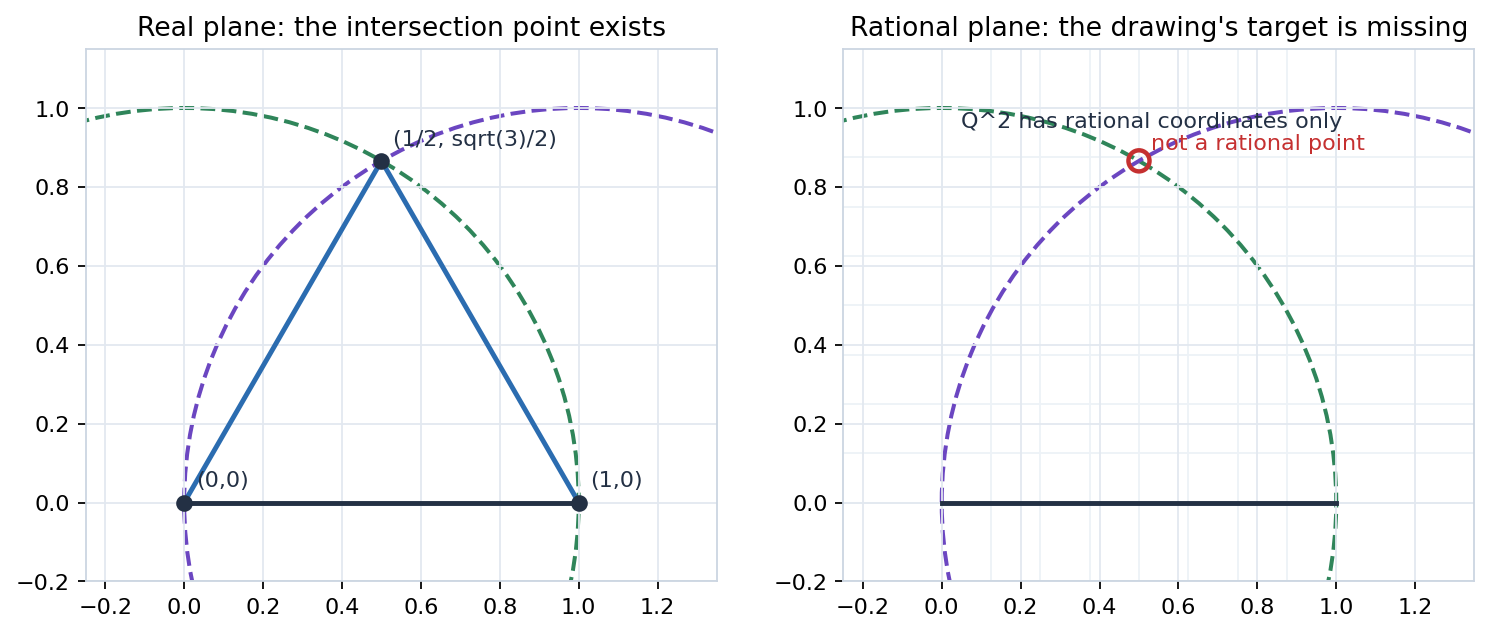

In [6]:
display_artifact(implicit_path, width=920)


## 3. Proof Dependencies As A Graph

The opening chapter repeatedly asks what a proof is allowed to use. A dependency graph makes the issue concrete. Some arrows point to explicit Euclidean starting data: definitions, postulates, and common notions. Other arrows mark assumptions a modern reader notices in Euclid's practice: circle intersections, superposition by rigid motion, and betweenness/order facts visible in diagrams.

Inspect the red assumption nodes. They are not defects in the notebook's computations; they are the places where a picture silently asks the theory for more than it has stated.


In [7]:
G = nx.DiGraph()
node_data = {
    "definitions": ("Definitions\npoint, line, angle", "foundation"),
    "postulates_1_3": ("Postulates 1-3\nstraightedge + compass", "foundation"),
    "common_notions": ("Common notions\nequality arithmetic", "foundation"),
    "circle_intersections": ("Circle/line intersections\nexist when the picture needs them", "hidden"),
    "superposition": ("Superposition\nrigid motions preserve data", "hidden"),
    "betweenness": ("Betweenness/order\ninside, outside, between", "hidden"),
    "parallel_postulate": ("Postulate 5\nparallel criterion", "foundation"),
    "I1": ("I.1\nequilateral triangle", "construction"),
    "I2": ("I.2\ntransfer a segment", "construction"),
    "I4": ("I.4\nSAS", "theorem"),
    "I9": ("I.9\nangle bisector", "construction"),
    "I27_I31": ("I.27-I.31\nparallel facts + construction", "theorem"),
    "I32": ("I.32\ntriangle angle sum", "theorem"),
    "I47": ("I.47\nPythagorean theorem", "theorem"),
    "IV10": ("IV.10\n36-72-72 triangle", "construction"),
    "IV11": ("IV.11\nregular pentagon", "construction"),
    "newer_centers": ("Section 5\ncentroid, orthocenter, Euler line", "theorem"),
    "nine_point": ("5.9\nnine-point circle", "theorem"),
}
for node, (label, kind) in node_data.items():
    G.add_node(node, label=label, kind=kind)
G.add_edges_from([
    ("definitions", "I1"), ("postulates_1_3", "I1"), ("circle_intersections", "I1"), ("common_notions", "I1"),
    ("I1", "I2"), ("postulates_1_3", "I2"), ("common_notions", "I2"),
    ("superposition", "I4"), ("common_notions", "I4"),
    ("I1", "I9"), ("I2", "I9"), ("circle_intersections", "I9"),
    ("betweenness", "I27_I31"), ("parallel_postulate", "I27_I31"),
    ("I27_I31", "I32"), ("parallel_postulate", "I32"),
    ("I32", "I47"), ("common_notions", "I47"),
    ("I47", "IV10"), ("I2", "IV10"), ("circle_intersections", "IV10"),
    ("IV10", "IV11"), ("I9", "IV11"), ("I32", "IV11"),
    ("I27_I31", "newer_centers"), ("I4", "newer_centers"),
    ("newer_centers", "nine_point"), ("betweenness", "nine_point"),
])

layers = {"foundation": 0, "hidden": 1, "construction": 2, "theorem": 3}
for node in G.nodes:
    G.nodes[node]["layer"] = layers[G.nodes[node]["kind"]]
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.6)
for node, xy in pos.items():
    pos[node] = np.array([xy[0], xy[1] * 1.55])

kind_colors = {"foundation": "#dbeafe", "hidden": "#fee2e2", "construction": "#dcfce7", "theorem": "#fef3c7"}
fig, ax = plt.subplots(figsize=(12, 7.2))
node_colors = [kind_colors[G.nodes[n]["kind"]] for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=13, width=1.2, edge_color="#64748b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2500, edgecolors="#334155", linewidths=1.0)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["label"] for n in G.nodes}, font_size=8.4, ax=ax)
ax.set_title("Dependency graph: explicit starts, hidden assumptions, and later propositions")
ax.axis("off")
proof_graph_path = save_matplotlib(fig, UNIT, "figures", "proof-dependency-graph.png", root=ARTIFACT_ROOT)
plt.close(fig)

graph_checks = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "hidden_assumption_nodes": [n for n in G.nodes if G.nodes[n]["kind"] == "hidden"],
    "regular_pentagon_dependencies": sorted(nx.ancestors(G, "IV11")),
}
proof_graph_check_path = save_json(graph_checks, UNIT, "checks", "proof-dependency-graph.json", root=ARTIFACT_ROOT)

graph_checks


{'node_count': 18,
 'edge_count': 28,
 'is_directed_acyclic_graph': True,
 'hidden_assumption_nodes': ['circle_intersections',
  'superposition',
  'betweenness'],
 'regular_pentagon_dependencies': ['I1',
  'I2',
  'I27_I31',
  'I32',
  'I47',
  'I9',
  'IV10',
  'betweenness',
  'circle_intersections',
  'common_notions',
  'definitions',
  'parallel_postulate',
  'postulates_1_3']}

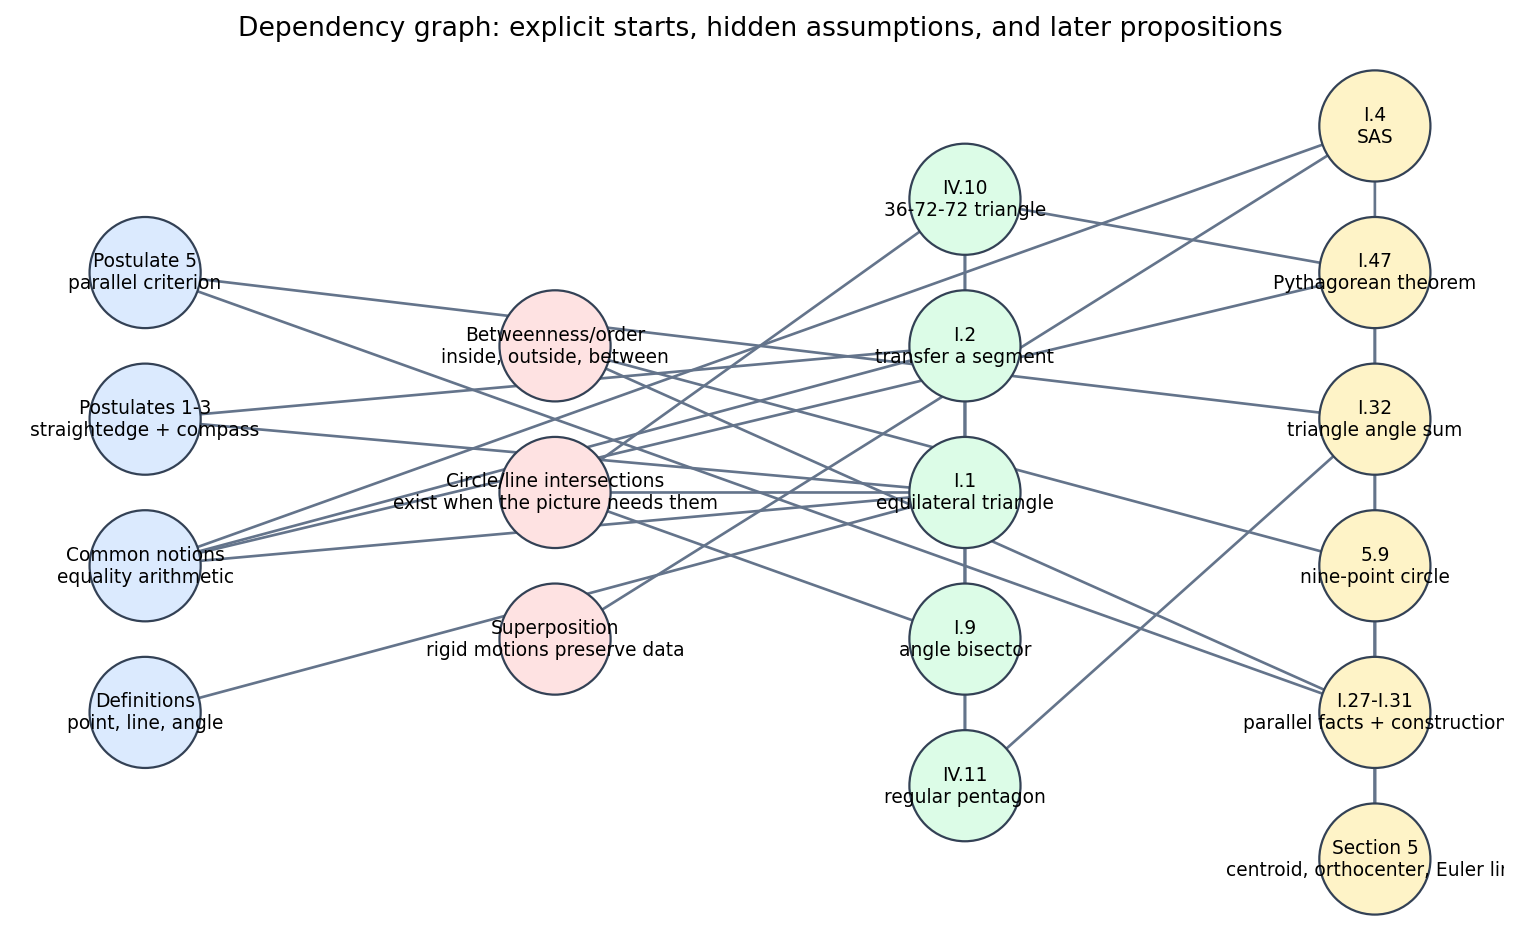

In [8]:
display_artifact(proof_graph_path, width=980)


## 4. The Pentagon And The Golden Triangle

The regular pentagon in Book IV is not just five equal chords. Its construction is routed through a special isosceles triangle: the vertex angle is half each base angle. Since the angles sum to two right angles, the triple must be `36, 72, 72` degrees. That is exactly the triangle that appears inside a regular pentagon.

The symbolic check below records the algebraic shadow of Euclid's area arguments: the diagonal-to-side ratio of a regular pentagon is the golden ratio. The diagram also contrasts two economies from the source span: Euclid's proof-friendly construction uses many primitive steps, while a compressed construction can reuse the same logic in fewer steps.


In [9]:
phi = (1 + sp.sqrt(5)) / 2
pent_angles = sp.Matrix([sp.pi / 5, 2 * sp.pi / 5, 2 * sp.pi / 5])
side_expr = 2 * sp.sin(sp.pi / 5)
diagonal_expr = 2 * sp.sin(2 * sp.pi / 5)
golden_checks_symbolic = {
    "angle_sum_minus_pi": str(sp.simplify(sum(pent_angles) - sp.pi)),
    "base_angle_minus_twice_vertex": str(sp.simplify(pent_angles[1] - 2 * pent_angles[0])),
    "diagonal_over_side_minus_phi": str(sp.simplify(diagonal_expr / side_expr - phi)),
}

angles = np.pi / 2 + 2 * np.pi * np.arange(5) / 5
pentagon = np.column_stack([np.cos(angles), np.sin(angles)])
side_lengths = np.array([distance(pentagon[i], pentagon[(i + 1) % 5]) for i in range(5)])
diagonal_lengths = np.array([distance(pentagon[i], pentagon[(i + 2) % 5]) for i in range(5)])

fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.3))
ax = axes[0]
v = np.array([0.0, math.tan(math.radians(72)) / 2])
left = np.array([-0.5, 0.0])
right = np.array([0.5, 0.0])
draw_polygon(ax, [v, left, right], color=PALETTE["blue"], fill="#dbeafe")
for point, name, offset in [(v, "36 deg", (-0.12, 0.08)), (left, "72 deg", (-0.23, -0.12)), (right, "72 deg", (0.04, -0.12))]:
    label_point(ax, point, name, offset=offset)
annotate_equal_marks(ax, [(v, left), (v, right)])
ax.text(0, -0.35, "base angles are twice the vertex angle", ha="center", color=PALETTE["ink"], fontsize=10)
ax.set_title("Golden triangle required by the pentagon proof")
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.45, 1.8)
set_equal_axes(ax, margin=0.05)

ax = axes[1]
unit_circle = Circle((0, 0), 1, fill=False, edgecolor=PALETTE["gray"], linestyle="--", lw=1.4)
ax.add_patch(unit_circle)
draw_polygon(ax, pentagon, color=PALETTE["blue"], fill="#dcfce7", linewidth=2.2)
for i in range(5):
    draw_segment(ax, pentagon[i], pentagon[(i + 2) % 5], color="#94a3b8", linewidth=1.0)
for i, p in enumerate(pentagon, start=1):
    label_point(ax, p, f"P{i}", offset=(0.035, 0.035))
ax.text(0, -1.28, "all five chords match; diagonal/side = phi", ha="center", color=PALETTE["ink"], fontsize=10)
ax.set_title("Regular pentagon certificate on a circle")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
set_equal_axes(ax, margin=0.05)

pentagon_path = save_matplotlib(fig, UNIT, "figures", "pentagon-golden-certificate.png", root=ARTIFACT_ROOT)
plt.close(fig)

pentagon_checks = {
    "symbolic": golden_checks_symbolic,
    "numeric": {
        "max_side_minus_min_side": float(side_lengths.max() - side_lengths.min()),
        "max_diagonal_minus_min_diagonal": float(diagonal_lengths.max() - diagonal_lengths.min()),
        "diagonal_over_side_minus_phi": float(diagonal_lengths.mean() / side_lengths.mean() - float(phi.evalf())),
        "area": polygon_area(pentagon),
    },
    "source_oriented_step_counts": {"proof_friendly_pentagon_path": 35, "compressed_pentagon_path": 14},
}
pentagon_check_path = save_json(pentagon_checks, UNIT, "checks", "pentagon-regularity.json", root=ARTIFACT_ROOT)

certificate_rows.extend([
    {"certificate": "regular_pentagon_in_circle", "step": "1-5", "operation": "construct tangent and copy the base angle of the golden triangle", "created": "an inscribed triangle with the required angle pattern", "depends_on": "circle tangent construction; angle-copy construction; golden triangle", "obligation": "inscribed triangle has angles 36,72,72 in the intended positions"},
    {"certificate": "regular_pentagon_in_circle", "step": "6-9", "operation": "bisect the two base angles on the circle", "created": "two additional circle points", "depends_on": "angle bisector construction; circle intersections", "obligation": "five arcs are equal, hence five chords are equal"},
    {"certificate": "regular_pentagon_in_circle", "step": "10-14", "operation": "join consecutive circle points", "created": "regular pentagon", "depends_on": "straightedge postulate; equal arc/equal chord theorem", "obligation": "all side residuals and angle residuals vanish"},
])

pentagon_checks


{'symbolic': {'angle_sum_minus_pi': '0',
  'base_angle_minus_twice_vertex': '0',
  'diagonal_over_side_minus_phi': '0'},
 'numeric': {'max_side_minus_min_side': 2.220446049250313e-16,
  'max_diagonal_minus_min_diagonal': 2.220446049250313e-16,
  'diagonal_over_side_minus_phi': 0.0,
  'area': 2.377641290737884},
 'source_oriented_step_counts': {'proof_friendly_pentagon_path': 35,
  'compressed_pentagon_path': 14}}

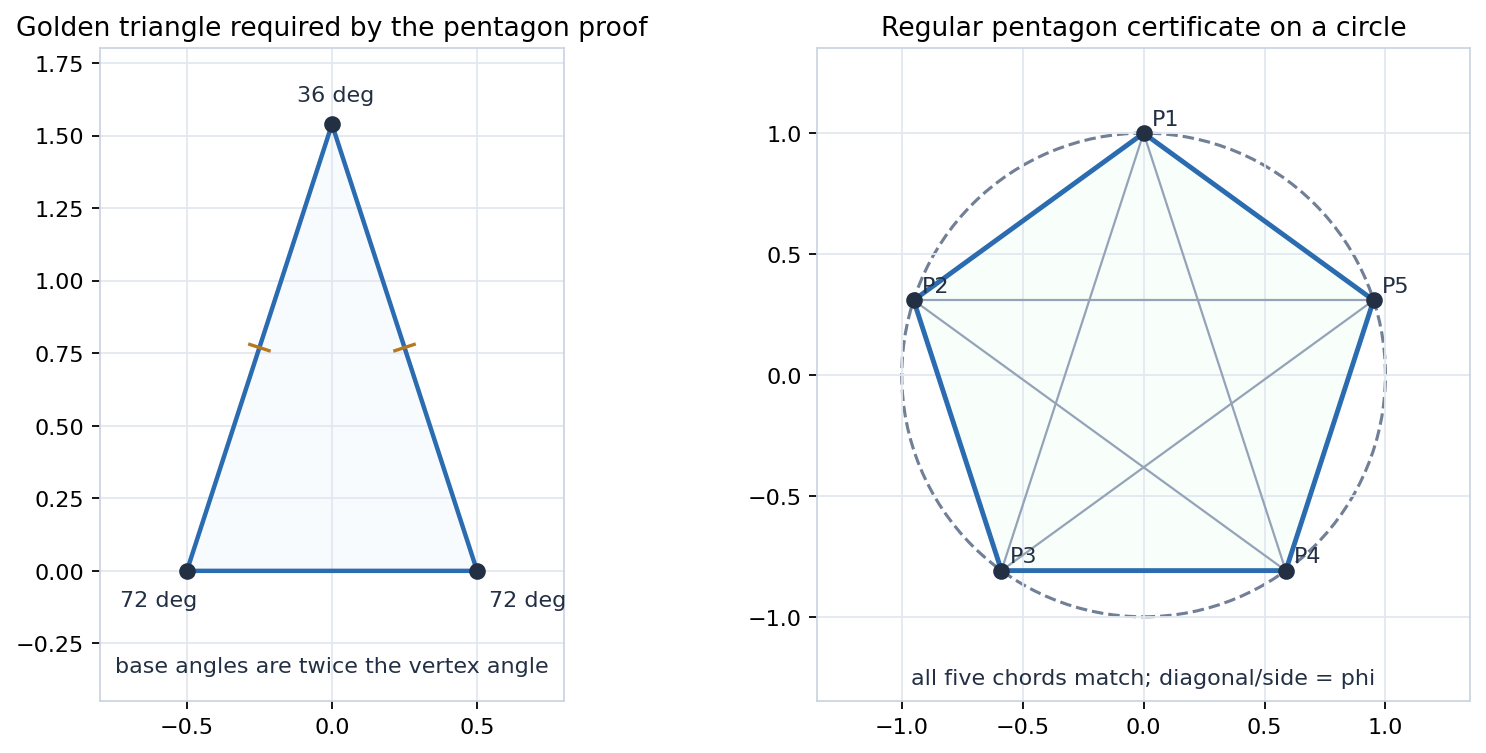

In [10]:
display_artifact(pentagon_path, width=960)


## 5. Newer Results: Centers As A Checkable Configuration

The final section uses Euclidean methods to prove results that are now standard in school geometry: midlines, medians meeting at the centroid, altitudes meeting at the orthocenter, the Euler line, cyclic quadrilaterals, and the nine-point circle.

The following computation does not replace the synthetic proofs. It gives a certificate for the configuration: the centroid must cut each median in a `2:1` ratio, the circumcenter, centroid, and orthocenter must be collinear with `GH = 2 OG`, and nine named points must lie on one circle.


In [11]:
TA = np.array([0.35, 2.95])
TB = np.array([-1.25, 0.0])
TC = np.array([3.15, 0.28])
O = circumcenter(TA, TB, TC)
Gcent = (TA + TB + TC) / 3
H = TA + TB + TC - 2 * O
X = (O + H) / 2
R = distance(O, TA)
nine_radius = R / 2

Dmid = (TB + TC) / 2
Emid = (TA + TC) / 2
Fmid = (TA + TB) / 2
Kfoot = foot_to_line(TA, TB, TC)
Lfoot = foot_to_line(TB, TA, TC)
Mfoot = foot_to_line(TC, TA, TB)
Pmid = (TA + H) / 2
Qmid = (TB + H) / 2
Rmid = (TC + H) / 2
nine_points = {
    "side_mid_D": Dmid,
    "side_mid_E": Emid,
    "side_mid_F": Fmid,
    "altitude_foot_K": Kfoot,
    "altitude_foot_L": Lfoot,
    "altitude_foot_M": Mfoot,
    "vertex_orthocenter_mid_P": Pmid,
    "vertex_orthocenter_mid_Q": Qmid,
    "vertex_orthocenter_mid_R": Rmid,
}

fig, ax = new_figure(9.0, 6.2)
draw_polygon(ax, [TA, TB, TC], color=PALETTE["ink"], fill="#f8fafc", linewidth=2.2)
for point, name, offset in [(TA, "A", (0.04, 0.04)), (TB, "B", (-0.12, -0.12)), (TC, "C", (0.04, -0.08))]:
    label_point(ax, point, name, offset=offset)
for vertex, mid in [(TA, Dmid), (TB, Emid), (TC, Fmid)]:
    draw_segment(ax, vertex, mid, color=PALETTE["green"], linewidth=1.4, linestyle="--")
for vertex, foot in [(TA, Kfoot), (TB, Lfoot), (TC, Mfoot)]:
    draw_segment(ax, vertex, foot, color=PALETTE["red"], linewidth=1.2, linestyle=":")
draw_extended_line(ax, O, H, color=PALETTE["purple"], lw=1.6, linestyle="-.")
ax.add_patch(Circle(X, nine_radius, fill=False, edgecolor=PALETTE["blue"], lw=2.0))
ax.add_patch(Circle(O, R, fill=False, edgecolor="#cbd5e1", lw=1.0, linestyle="--"))
for point, name, offset in [(O, "O", (0.04, 0.04)), (Gcent, "G", (0.04, -0.08)), (H, "H", (0.04, 0.04)), (X, "X", (0.04, 0.04))]:
    label_point(ax, point, name, offset=offset)
for name, point in nine_points.items():
    short = name.split("_")[-1]
    ax.scatter([point[0]], [point[1]], s=28, color=PALETTE["blue"], zorder=4)
    ax.text(point[0] + 0.035, point[1] + 0.035, short, fontsize=8, color=PALETTE["blue"])
ax.text(1.25, 2.72, "Euler line: O, G, H", color=PALETTE["purple"], fontsize=10)
ax.text(1.05, -0.38, "nine points share center X and radius R/2", color=PALETTE["blue"], fontsize=10)
ax.set_title("Section 5 certificate: Euler line and nine-point circle")
ax.set_xlim(-1.75, 3.65)
ax.set_ylim(-0.75, 3.35)
set_equal_axes(ax, margin=0.05)
euler_path = save_matplotlib(fig, UNIT, "figures", "euler-line-nine-point-certificate.png", root=ARTIFACT_ROOT)
plt.close(fig)

nine_distances = {name: distance(point, X) for name, point in nine_points.items()}
median_ratio_residuals = {
    "AG_over_GD_minus_2": distance(TA, Gcent) / distance(Gcent, Dmid) - 2,
    "BG_over_GE_minus_2": distance(TB, Gcent) / distance(Gcent, Emid) - 2,
    "CG_over_GF_minus_2": distance(TC, Gcent) / distance(Gcent, Fmid) - 2,
}
euler_checks = {
    "euler_line": {"orientation_O_G_H": orientation(O, Gcent, H), "GH_minus_2OG": distance(Gcent, H) - 2 * distance(O, Gcent)},
    "centroid_median_ratio_residuals": median_ratio_residuals,
    "nine_point_circle": {
        "radius": nine_radius,
        "max_distance_minus_min_distance": max(nine_distances.values()) - min(nine_distances.values()),
        "distance_minus_radius": {name: value - nine_radius for name, value in nine_distances.items()},
    },
}
euler_check_path = save_json(euler_checks, UNIT, "checks", "euler-line-nine-point.json", root=ARTIFACT_ROOT)

euler_checks


{'euler_line': {'orientation_O_G_H': 2.7755575615628914e-17,
  'GH_minus_2OG': -2.220446049250313e-16},
 'centroid_median_ratio_residuals': {'AG_over_GD_minus_2': -2.220446049250313e-16,
  'BG_over_GE_minus_2': 0.0,
  'CG_over_GF_minus_2': 4.440892098500626e-16},
 'nine_point_circle': {'radius': 1.1419898011880227,
  'max_distance_minus_min_distance': 4.440892098500626e-16,
  'distance_minus_radius': {'side_mid_D': 2.220446049250313e-16,
   'side_mid_E': 0.0,
   'side_mid_F': -2.220446049250313e-16,
   'altitude_foot_K': 0.0,
   'altitude_foot_L': 0.0,
   'altitude_foot_M': 0.0,
   'vertex_orthocenter_mid_P': 0.0,
   'vertex_orthocenter_mid_Q': 0.0,
   'vertex_orthocenter_mid_R': 0.0}}}

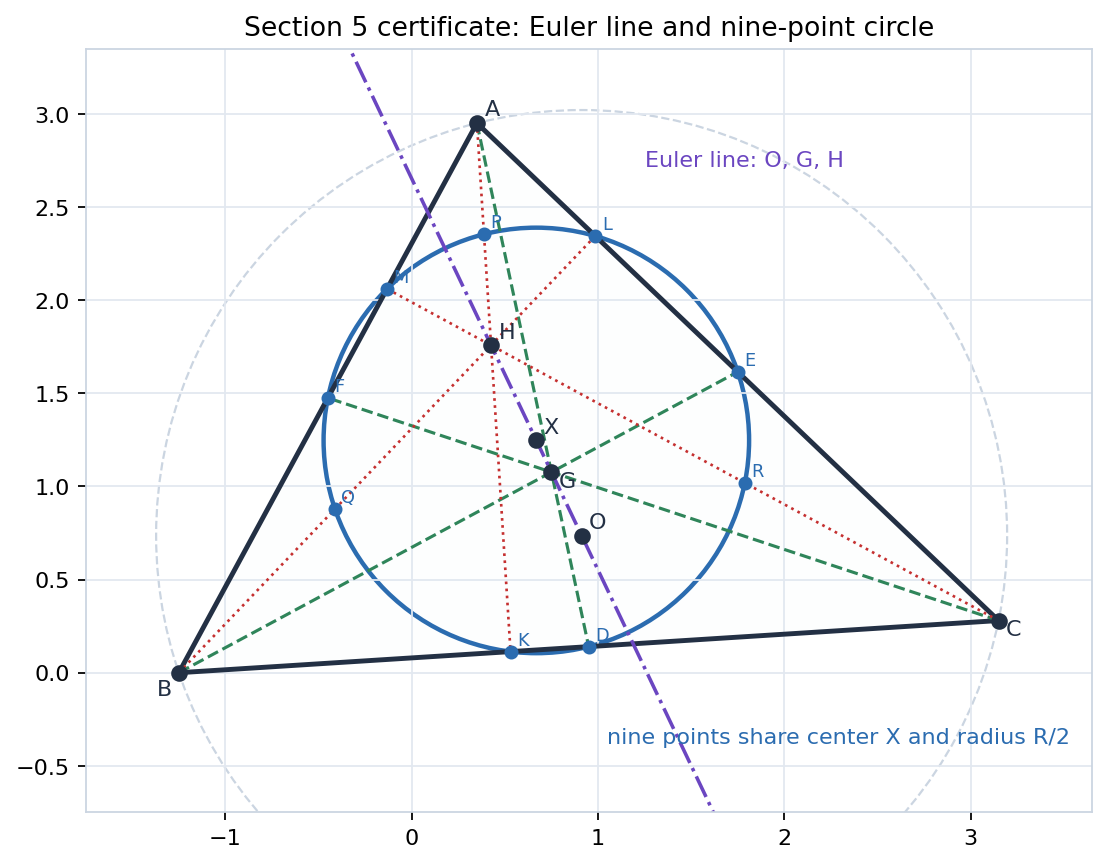

In [12]:
display_artifact(euler_path, width=920)


## Applied Lab: A Certificate Catches A Pretty Wrong Drawing

Euclid's chapter keeps returning to the difference between a persuasive drawing and an exact construction. In the lab, treat a regular pentagon as a data object and deliberately nudge one vertex. The failure is not visual at first glance; it appears in the certificate residuals.

The same pattern is useful for any ruler-and-compass construction: list the permitted operations, list the required equalities/incidences, and make the residuals visible.


In [13]:
def pentagon_certificate_residuals(points):
    points = np.asarray(points, dtype=float)
    sides = np.array([distance(points[i], points[(i + 1) % 5]) for i in range(5)])
    diagonals = np.array([distance(points[i], points[(i + 2) % 5]) for i in range(5)])
    radii = np.linalg.norm(points, axis=1)
    return {
        "side_spread": float(sides.max() - sides.min()),
        "radius_spread": float(radii.max() - radii.min()),
        "diagonal_side_ratio_residual": float(diagonals.mean() / sides.mean() - float(phi.evalf())),
    }

perturbed_pentagon = pentagon.copy()
perturbed_pentagon[2] += np.array([0.045, -0.025])
lab_rows = [
    {"case": "exact_regular_pentagon", **pentagon_certificate_residuals(pentagon)},
    {"case": "one_vertex_nudged", **pentagon_certificate_residuals(perturbed_pentagon)},
]
lab_table = pd.DataFrame(lab_rows)
lab_table_path = artifact_path(UNIT, "tables", "pentagon-certificate-lab.csv", root=ARTIFACT_ROOT)
lab_table.to_csv(lab_table_path, index=False)

certificate_table = pd.DataFrame(certificate_rows)
certificate_table_path = artifact_path(UNIT, "tables", "construction-certificates.csv", root=ARTIFACT_ROOT)
certificate_table.to_csv(certificate_table_path, index=False)

lab_summary = {
    "lab_table": book_local(lab_table_path),
    "certificate_table": book_local(certificate_table_path),
    "nudged_case_detected": lab_rows[1]["side_spread"] > 1e-3 and lab_rows[1]["radius_spread"] > 1e-3,
}
lab_check_path = save_json(lab_summary, UNIT, "checks", "applied-lab-summary.json", root=ARTIFACT_ROOT)

lab_table


,case,side_spread,radius_spread,diagonal_side_ratio_residual
0,exact_regular_pentagon,2.220446e-16,0.000000,0.000000
1,one_vertex_nudged,8.291262e-02,0.004912,-0.000004


In [14]:
certificate_table[["certificate", "step", "operation", "obligation"]]


,certificate,step,operation,obligation
0,equilateral_on_AB,1,"circle(center=A, radius=AB)",AB is a positive radius
1,equilateral_on_AB,2,"circle(center=B, radius=BA)",two circles meet
2,equilateral_on_AB,3,"line(A,C)",A and C are distinct
3,equilateral_on_AB,4,"line(B,C)",B and C are distinct; AC=AB=BC
4,regular_pentagon_in_circle,1-5,construct tangent and copy the base angle of t...,"inscribed triangle has angles 36,72,72 in the ..."
5,regular_pentagon_in_circle,6-9,bisect the two base angles on the circle,"five arcs are equal, hence five chords are equal"
6,regular_pentagon_in_circle,10-14,join consecutive circle points,all side residuals and angle residuals vanish


## Final Sanity Checks

The final cell checks the notebook's core claims: artifacts exist and are nonempty, symbolic residuals vanish, the dependency graph is acyclic, the pentagon residuals are small, and the Euler-line/nine-point residuals are within numerical tolerance.


In [15]:
required_artifacts = [
    equilateral_path,
    implicit_path,
    proof_graph_path,
    pentagon_path,
    euler_path,
    equilateral_check_path,
    implicit_check_path,
    proof_graph_check_path,
    pentagon_check_path,
    euler_check_path,
    lab_check_path,
    lab_table_path,
    certificate_table_path,
]

artifact_sizes = {}
for path in required_artifacts:
    min_bytes = 64 if path.suffix.lower() in {".json", ".csv"} else 512
    artifact_sizes[book_local(assert_artifact(path, min_bytes=min_bytes))] = path.stat().st_size

assert equilateral_checks["numeric"]["intersection_count"] == 2
assert close_enough(equilateral_checks["numeric"]["AB_minus_AC"])
assert close_enough(equilateral_checks["numeric"]["AB_minus_BC"])
assert equilateral_checks["symbolic"]["AC_squared_minus_AB_squared"] == "0"
assert equilateral_checks["symbolic"]["BC_squared_minus_AB_squared"] == "0"
assert not implicit_checks["rational_plane_countermodel"]["candidate_y_is_rational"]
assert graph_checks["is_directed_acyclic_graph"]
assert pentagon_checks["symbolic"]["angle_sum_minus_pi"] == "0"
assert pentagon_checks["symbolic"]["base_angle_minus_twice_vertex"] == "0"
assert pentagon_checks["symbolic"]["diagonal_over_side_minus_phi"] == "0"
assert pentagon_checks["numeric"]["max_side_minus_min_side"] < 1e-12
assert pentagon_checks["numeric"]["max_diagonal_minus_min_diagonal"] < 1e-12
assert abs(euler_checks["euler_line"]["orientation_O_G_H"]) < 1e-10
assert abs(euler_checks["euler_line"]["GH_minus_2OG"]) < 1e-10
assert euler_checks["nine_point_circle"]["max_distance_minus_min_distance"] < 1e-10
assert lab_summary["nudged_case_detected"]

visual_checks = {
    "unit": UNIT,
    "source_span": "printed pages 7-64; PDF pages 19-76; sections 1-5",
    "figures": [book_local(p) for p in [equilateral_path, implicit_path, proof_graph_path, pentagon_path, euler_path]],
    "checks": [book_local(p) for p in [equilateral_check_path, implicit_check_path, proof_graph_check_path, pentagon_check_path, euler_check_path, lab_check_path]],
}
visual_checks_path = save_json(visual_checks, UNIT, "checks", "visual-checks.json", root=ARTIFACT_ROOT)
artifact_sizes[book_local(visual_checks_path)] = visual_checks_path.stat().st_size

final_sanity = {
    "unit": UNIT,
    "source_span": visual_checks["source_span"],
    "artifact_count": len(required_artifacts) + 1,
    "artifact_sizes": artifact_sizes,
    "core_residuals": {
        "equilateral_max_length_residual": max(abs(equilateral_checks["numeric"]["AB_minus_AC"]), abs(equilateral_checks["numeric"]["AB_minus_BC"])),
        "pentagon_side_spread": pentagon_checks["numeric"]["max_side_minus_min_side"],
        "euler_line_orientation": euler_checks["euler_line"]["orientation_O_G_H"],
        "nine_point_spread": euler_checks["nine_point_circle"]["max_distance_minus_min_distance"],
    },
    "passed": True,
}
notebook_sanity_path = save_json(final_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)
final_sanity["artifact_sizes"][book_local(notebook_sanity_path)] = notebook_sanity_path.stat().st_size
save_json(final_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)

final_sanity


{'unit': 'chapter-01',
 'source_span': 'printed pages 7-64; PDF pages 19-76; sections 1-5',
 'artifact_count': 14,
 'artifact_sizes': {'artifacts/chapter-01/figures/equilateral-construction-certificate.png': 82921,
  'artifacts/chapter-01/figures/implicit-intersection-assumptions.png': 96868,
  'artifacts/chapter-01/figures/proof-dependency-graph.png': 274499,
  'artifacts/chapter-01/figures/pentagon-golden-certificate.png': 129409,
  'artifacts/chapter-01/figures/euler-line-nine-point-certificate.png': 148190,
  'artifacts/chapter-01/checks/equilateral-certificate.json': 324,
  'artifacts/chapter-01/checks/implicit-intersection-assumptions.json': 457,
  'artifacts/chapter-01/checks/proof-dependency-graph.json': 462,
  'artifacts/chapter-01/checks/pentagon-regularity.json': 474,
  'artifacts/chapter-01/checks/euler-line-nine-point.json': 796,
  'artifacts/chapter-01/checks/applied-lab-summary.json': 197,
  'artifacts/chapter-01/tables/pentagon-certificate-lab.csv': 198,
  'artifacts/ch

## Takeaways

- Euclid's constructive propositions are existence proofs with a tool discipline: straightedge operations create lines, compass operations create circles, and intersections need explicit permission from the theory.
- A construction certificate separates the drawing from the proof obligation; equal-looking segments are not enough until the relevant radii, common notions, or chord theorems explain them.
- The first equilateral triangle already exposes hidden assumptions: over the rational coordinate plane the desired intersection is absent.
- The regular pentagon is governed by the `36-72-72` golden triangle; its diagonal-to-side ratio is exactly the golden ratio.
- Later triangle-center results fit the same pattern: centroid, orthocenter, Euler line, and nine-point circle can all be tested as incidence, ratio, and equal-radius certificates.
